In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib as mpl
import glob
import random
import datetime as dt

import sys
sys.path.append("./libraries/")
import cloud_processing_lib as cpl
import sun_position_calc as sun

from scipy.signal import argrelextrema
from numpy.lib.stride_tricks import sliding_window_view

In [3]:
root_dir = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/"
path_collector = glob.glob(root_dir + "2026/**/*.png", recursive=True)

mask_old = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_old.png")
mask_new = cpl.prepare_mask("/home/sdoeding/analysis_scripts/auxiliary/mask_new.png")

mappings = cpl.calc_mappings(95, 80, 1520, "equidistant")

duplicates = cpl.prepare_duplicates("/home/sdoeding/analysis_scripts/auxiliary/duplicates_out.csv")

In [56]:
#sel_path = random.choice(path_collector)
#sel_path = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/05/19/10/20260519_100530.png"
#sel_path = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/06/09/13/20260609_131700.png"
#sel_path = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/06/01/10/20260601_100000.png"
#sel_path = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/05/26/12/20260526_120000.png"
#sel_path = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/01/25/12/20260125_120000.png"
sel_path = "/projekt1/ag_maahn/data_obs/lim/allsky1/images/2026/06/01/11/20260601_113000.png"

cur_timestamp = dt.datetime.strptime(sel_path[-19:-4], "%Y%m%d_%H%M%S")

if (cur_timestamp - dt.datetime(2026,4,20)).total_seconds() < 0:
    sel_mask = mask_old
else:
    sel_mask = mask_new
    
lumi, img_crp, rb_hist, brbg_hist, rb_layer, brbg_layer,\
cld_rb_layer, cld_brbg_layer, rb_fraction, brbg_fraction = cpl.calc_fractions(sel_path, sel_mask, mappings, duplicates, debug=True)

In [57]:
## prepare for plotting

p05 = np.nanpercentile(lumi, 5)
p95 = np.nanpercentile(lumi, 95)

field_new = (np.clip((img_crp - p05) / (p95 - p05), 0, 1) * 255).astype("uint8")
field_new = cv2.addWeighted(field_new, 1.1, np.zeros(field_new.shape, field_new.dtype), 0, 40)

# rb cmap
rb_cmap = plt.get_cmap("plasma", 8)
rb_sm = mpl.cm.ScalarMappable(cmap=rb_cmap, norm=mpl.colors.Normalize(0.7, 1.1))

# brbg cmap
brbg_cmap = plt.get_cmap("plasma_r", 10)
brbg_sm = mpl.cm.ScalarMappable(cmap=brbg_cmap, norm=mpl.colors.Normalize(1.5,2.5))

/tmp/ipykernel_1321359/3212012664.py:6: RuntimeWarning: invalid value encountered in cast
  field_new = (np.clip((img_crp - p05) / (p95 - p05), 0, 1) * 255).astype("uint8")


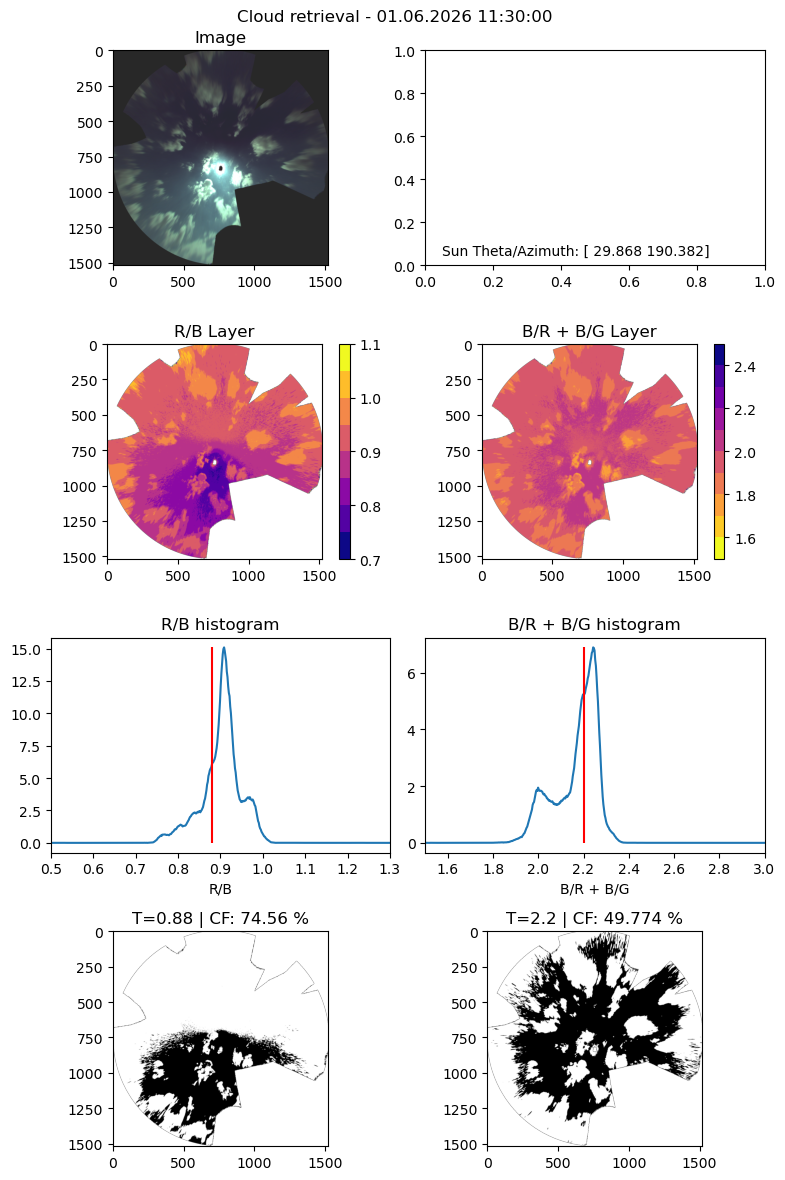

In [58]:
# Plot retrieval data

fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(8,12))

fig.suptitle("Cloud retrieval - " + cur_timestamp.strftime("%d.%m.%Y %H:%M:%S"))

# Original Image
ax[0,0].set_title("Image")
ax[0,0].imshow(field_new)

# Metadata
ax[0,1].text(0.05,0.1,"Sun Theta/Azimuth: {0}".format(np.round(sun.calc_sun_pos(51.333276, 12.388643, cur_timestamp),3)),
             ha='left', va='top', transform=ax[0,1].transAxes)


# RB Layer
ax[1,0].imshow(rb_layer, vmin=0.7, vmax=1.1, cmap=rb_cmap)
fig.colorbar(rb_sm, ax=ax[1,0])
#ax[1,0].colorbar(rb_sm)
ax[1,0].set_title("R/B Layer")


# RB histogram
ax[2,0].plot(np.linspace(0.5,1.3,500), rb_hist[0])
#ax[2,0].vlines([rb_hist[1][thr] for thr in rb_candidates], 0, np.max(rb_hist[0]), color="gray")
ax[2,0].vlines(0.88, 0, np.max(rb_hist[0]), color="red")
ax[2,0].set_title("R/B histogram")
ax[2,0].set_xlabel("R/B")
ax[2,0].set_xlim(0.5, 1.3)


# RB Clouds
ax[3,0].imshow(cld_rb_layer, cmap="binary_r")
ax[3,0].set_title("T={0} | CF: {1} %".format(np.round(0.88,3), rb_fraction))


# BRBG Layer
ax[1,1].imshow(brbg_layer, vmin=1.5, vmax=3.0, cmap = brbg_cmap)
fig.colorbar(brbg_sm, ax=ax[1,1])
#ax[1,1].colorbar(brbg_sm)
ax[1,1].set_title("B/R + B/G Layer")


# BRBG histogram
ax[2,1].plot(np.linspace(1.5,3.0,500), brbg_hist[0])
#ax[2,1].vlines([brbg_hist[1][thr] for thr in brbg_candidates], 0, np.max(brbg_hist[0]), color="gray")
ax[2,1].vlines(2.2, 0, np.max(brbg_hist[0]), color="red")
ax[2,1].set_title("B/R + B/G histogram")
ax[2,1].set_xlabel("B/R + B/G")
ax[2,1].set_xlim(1.5,3.0)


# BRBG Clouds
ax[3,1].imshow(cld_brbg_layer, cmap="binary_r")
ax[3,1].set_title("T={0} | CF: {1} %".format(2.2, brbg_fraction))


fig.tight_layout()

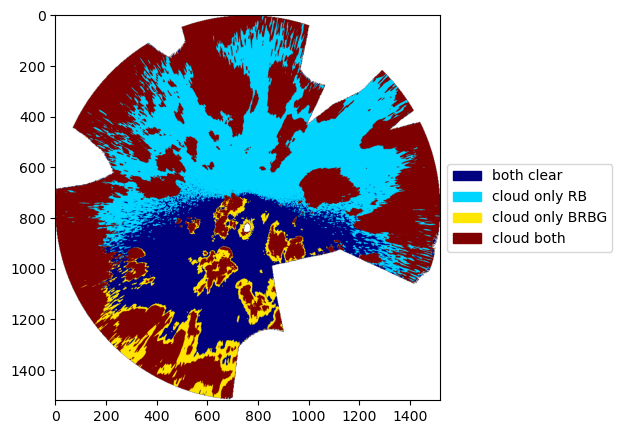

In [59]:
temp = cld_rb_layer + 2*cld_brbg_layer

values = [0,1,2,3]
labels=["both clear", "cloud only RB", "cloud only BRBG", "cloud both"]

plt.figure(figsize=(5,5))
im=plt.imshow(temp, cmap="jet")
colors = [im.cmap(im.norm(value)) for value in values]
patches = [ mpl.patches.Patch(color=colors[i], label=labels[i]) for i in range(len(values)) ]

plt.legend(handles=patches, bbox_to_anchor=(1, 0.5), loc="center left")
plt.savefig("outplot2.png")

In [60]:
xhalf=760

rect_foclen = 760 / np.tan(np.deg2rad(80))            # max theta in rectilinear is 65 for comparison with COMM

temp_raw = np.mgrid[0:1520,0:1520] - xhalf

xrel = temp_raw[0,:,:]
yrel = temp_raw[1,:,:]

rect_r = np.sqrt(xrel**2+yrel**2)
theta = np.atan(rect_r/rect_foclen) * 180 / np.pi

LinregressResult(slope=np.float64(-0.0018577381023568468), intercept=np.float64(2.3023066827390926), rvalue=np.float64(-0.13979067947389462), pvalue=np.float64(0.0), stderr=np.float64(1.096472469692805e-05), intercept_stderr=np.float64(0.0007897094717236951))


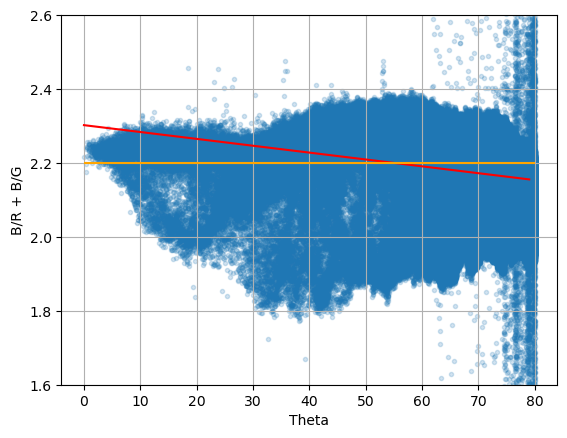

In [61]:
import scipy.stats as stat


lreg = stat.linregress(theta.flat, brbg_layer.flat, nan_policy="omit")
xgen=np.arange(0, 80, dtype="float")
ygen=lreg.slope*xgen+lreg.intercept


plt.scatter(theta.flat, brbg_layer.flat, alpha=0.2, marker=".")
plt.plot(xgen,ygen, color="red")

plt.ylim(1.6, 2.6)
plt.xlabel("Theta")
plt.ylabel("B/R + B/G")
plt.grid()

plt.hlines(2.2, 0, 80, color="orange")

print(lreg)

LinregressResult(slope=np.float64(0.0015824581554172972), intercept=np.float64(0.790824296258869), rvalue=np.float64(0.1954103540780035), pvalue=np.float64(0.0), stderr=np.float64(6.6164046631775885e-06), intercept_stderr=np.float64(0.0004765451167572089))


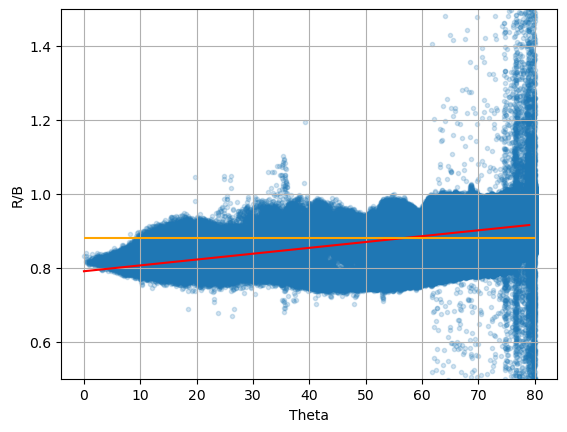

In [62]:
import scipy.stats as stat


lreg = stat.linregress(theta.flat, rb_layer.flat, nan_policy="omit")
xgen=np.arange(0, 80, dtype="float")
ygen=lreg.slope*xgen+lreg.intercept


plt.scatter(theta.flat, rb_layer.flat, alpha=0.2, marker=".")
plt.plot(xgen,ygen, color="red")

plt.ylim(0.5,1.5)
plt.xlabel("Theta")
plt.ylabel("R/B")
plt.grid()

plt.hlines(0.88, 0, 80, color="orange")

print(lreg)

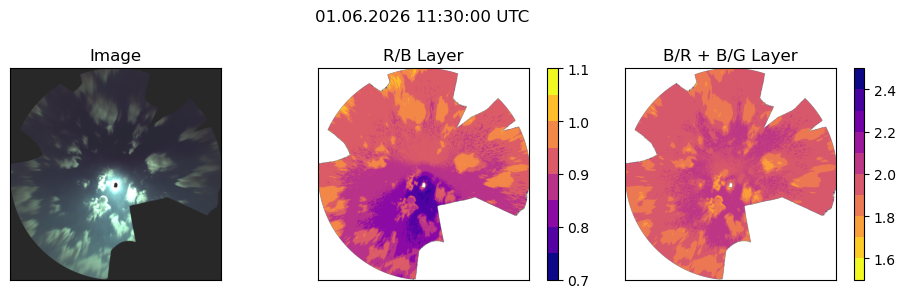

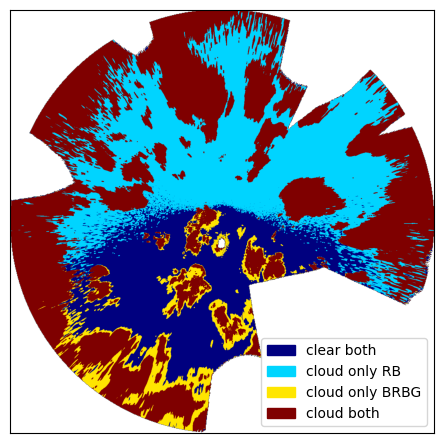

In [66]:
fig, ax = plt.subplots(ncols=3, nrows=1, tight_layout=True, figsize=(10,3))

ax[0].set_title("Image")
ax[0].imshow(field_new)
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].imshow(rb_layer, vmin=0.7, vmax=1.1, cmap=rb_cmap)
ax[1].set_title("R/B Layer")
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[2].imshow(brbg_layer, vmin=1.5, vmax=3.0, cmap = brbg_cmap)
ax[2].set_title("B/R + B/G Layer")
ax[2].set_xticks([])
ax[2].set_yticks([])

# fig.colorbar(rb_sm, ax=ax[1], fraction=0.046, pad=0.04)
# fig.colorbar(brbg_sm, ax=ax[2], fraction=0.046, pad=0.04)

fig.colorbar(rb_sm, ax=ax[1], orientation="vertical")
fig.colorbar(brbg_sm, ax=ax[2], orientation="vertical")

fig.suptitle(cur_timestamp.strftime("%d.%m.%Y %H:%M:%S") + " UTC")

fig.savefig("rb_bad_example.png")




temp = cld_rb_layer + 2*cld_brbg_layer

values = [0,1,2,3]
labels=["clear both", "cloud only RB", "cloud only BRBG", "cloud both"]

plt.figure(figsize=(5.5,5.5))
im=plt.imshow(temp, cmap="jet")
colors = [im.cmap(im.norm(value)) for value in values]
patches = [ mpl.patches.Patch(color=colors[i], label=labels[i]) for i in range(len(values)) ]
plt.xticks([])
plt.yticks([])

#plt.legend(handles=patches, bbox_to_anchor=(1, 0.5), loc="center left")
plt.legend(handles=patches, loc="lower right")
plt.savefig("algorithm_comp.png")

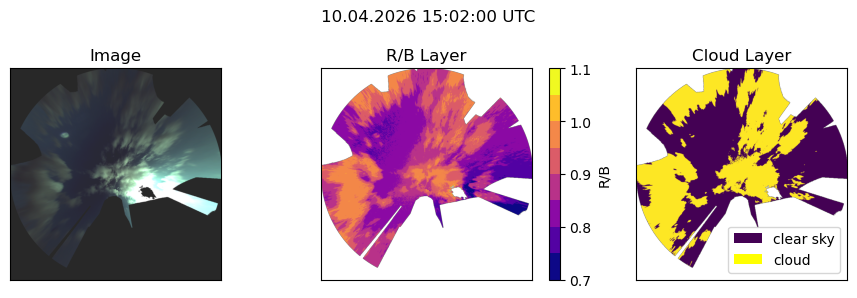

In [54]:
from matplotlib.patches import Patch
fig, ax = plt.subplots(ncols=3, nrows=1, tight_layout=True, figsize=(10,3))

ax[0].set_title("Image")
ax[0].imshow(field_new)
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].imshow(rb_layer, vmin=0.7, vmax=1.1, cmap=rb_cmap)
ax[1].set_title("R/B Layer")
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[2].imshow(cld_rb_layer)
ax[2].set_title("Cloud Layer")
ax[2].set_xticks([])
ax[2].set_yticks([])

fig.colorbar(rb_sm, ax=ax[1], orientation="vertical", label="R/B")
legend_handles = [Patch(facecolor=mpl.cm.viridis(0.0), label="clear sky"), Patch(facecolor="yellow", label="cloud")]
ax[2].legend(handles=legend_handles, loc="lower right")

fig.suptitle(cur_timestamp.strftime("%d.%m.%Y %H:%M:%S") + " UTC")

fig.savefig("rb_good_example.png")